# LogisticRegression — Feature Selection

**Prerequisite:** Run `data/01_build_features.ipynb` to generate `data/latest_features.jsonl`.

**Goal:** Find the optimal feature set for LogisticRegression.

**Method:** Forward selection (greedy). Unlike RF/XGB, linear models don't have built-in feature importance,
so we use forward selection — starting with an empty set, greedily adding the feature that gives the
biggest accuracy improvement, then finding the peak before overfitting.

**Metric:** Per-snapshot accuracy (same as RF and XGB notebooks).

**Output:** `data/optimal_features_lr.json` with features and default hyperparameters.


In [1]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json as _json
import random
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")

## 1. Load data and train/val split

In [2]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(_json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
train_ids = set(candle_ids[:split_idx])

df_train = df[df["candle_id"].isin(train_ids)]
df_val = df[~df["candle_id"].isin(train_ids)]

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[all_feat_cols].values)
y_train = df_train["target"].values
X_val = scaler.transform(df_val[all_feat_cols].values)
y_val = df_val["target"].values

print(f"Features: {len(all_feat_cols)}")
print(f"Train: {len(df_train):,} rows, {df_train['candle_id'].nunique()} candles")
print(f"Val:   {len(df_val):,} rows, {df_val['candle_id'].nunique()} candles")

Features: 60
Train: 53,236 rows, 1100 candles
Val:   12,917 rows, 276 candles


## 2. Baseline — all features

In [3]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_val, baseline.predict(X_val))
print(f"Baseline (all {len(all_feat_cols)} features): {baseline_acc * 100:.1f}% snapshot accuracy")

Baseline (all 60 features): 74.1% snapshot accuracy


## 3. Forward feature selection

> **Why forward selection for LR?** Unlike tree-based models (RF, XGB), LogisticRegression has no
> built-in feature importance metric. Forward selection greedily finds the optimal feature subset
> by testing all candidates at each step. This is O(N²) but reliable for linear models.

In [4]:
N_TOTAL = len(all_feat_cols)
selected_indices = []
selected_names = []
remaining = list(range(N_TOTAL))
history = []

for step in tqdm(range(N_TOTAL), desc="Forward selection"):
    best_acc = -1
    best_idx = -1

    for candidate in remaining:
        trial = selected_indices + [candidate]
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(X_train[:, trial], y_train)
        pred = m.predict(X_val[:, trial])
        acc = float(np.mean(pred == y_val))

        if acc > best_acc:
            best_acc = acc
            best_idx = candidate

    selected_indices.append(best_idx)
    selected_names.append(all_feat_cols[best_idx])
    remaining.remove(best_idx)
    history.append((step + 1, best_acc, all_feat_cols[best_idx]))

    if (step + 1) % 10 == 0 or step < 5:
        print(f"  Step {step + 1:>2}: +{all_feat_cols[best_idx]:<30} -> accuracy={best_acc * 100:.2f}%")

# Find optimal N by snapshot accuracy
accs_arr = [h[1] for h in history]
best_n = int(np.argmax(accs_arr)) + 1
best_acc_val = max(accs_arr)

print(f"\nOptimal: {best_n} features -> {best_acc_val * 100:.2f}% snapshot accuracy")
print(f"Baseline: {baseline_acc * 100:.2f}% (all {N_TOTAL})")
print(f"Improvement: {(best_acc_val - baseline_acc) * 100:+.2f}%")

Forward selection:   2%|▏         | 1/60 [00:00<00:07,  7.73it/s]

  Step  1: +btc_move_from_open             -> accuracy=75.37%


Forward selection:   3%|▎         | 2/60 [00:00<00:12,  4.75it/s]

  Step  2: +rr_spread                      -> accuracy=75.48%


Forward selection:   5%|▌         | 3/60 [00:00<00:16,  3.36it/s]

...

  Step 40: +peak_drawback                  -> accuracy=76.89%


Forward selection:  83%|████████▎ | 50/60 [00:30<00:07,  1.37it/s]

  Step 50: +down_implied_probability       -> accuracy=76.76%


Forward selection: 100%|██████████| 60/60 [00:34<00:00,  1.75it/s]

  Step 60: +up_spread_level                -> accuracy=74.10%

Optimal: 39 features -> 76.94% snapshot accuracy
Baseline: 74.09% (all 60)
Improvement: +2.85%


### Accuracy vs feature count

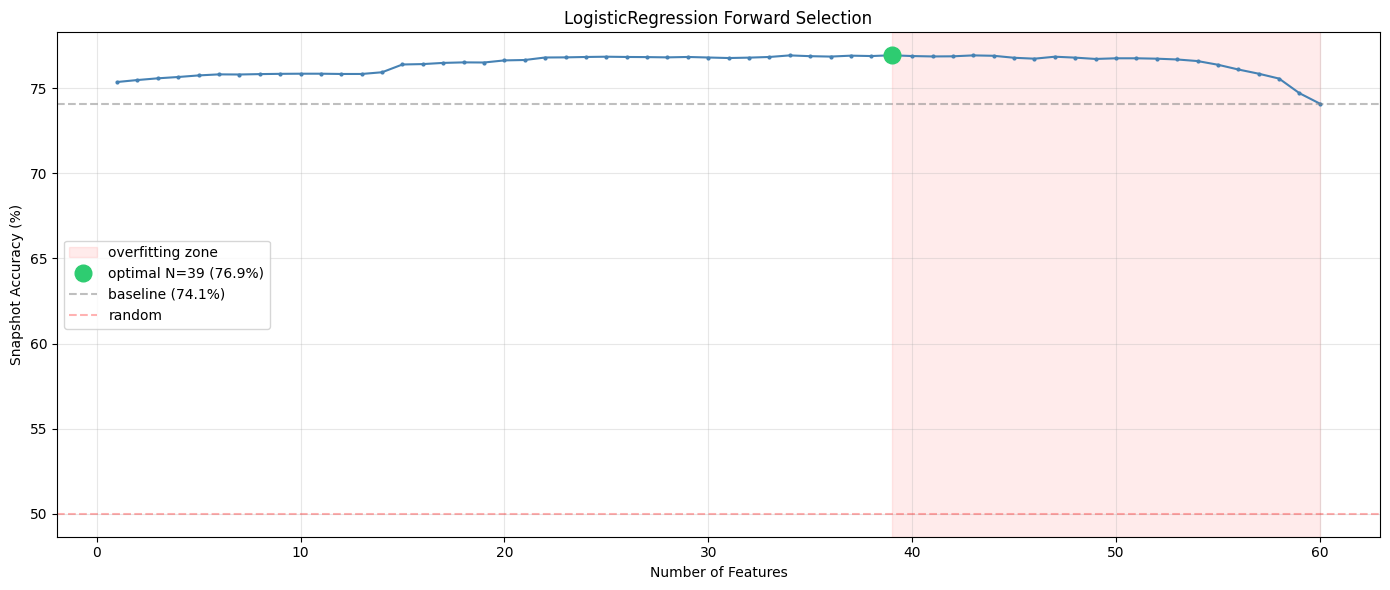

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
steps = [h[0] for h in history]
step_accs = [h[1] * 100 for h in history]

ax.axvspan(best_n, N_TOTAL, alpha=0.08, color="red", label="overfitting zone")
ax.plot(steps, step_accs, marker=".", color="steelblue", linewidth=1.5, markersize=4)
ax.plot(
    best_n,
    best_acc_val * 100,
    "o",
    color="#2ecc71",
    markersize=12,
    label=f"optimal N={best_n} ({best_acc_val * 100:.1f}%)",
)
ax.axhline(baseline_acc * 100, color="gray", linestyle="--", alpha=0.5, label=f"baseline ({baseline_acc * 100:.1f}%)")
ax.axhline(50, color="red", linestyle="--", alpha=0.3, label="random")
ax.set_xlabel("Number of Features")
ax.set_ylabel("Snapshot Accuracy (%)")
ax.set_title("LogisticRegression Forward Selection")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Evaluate optimal model

In [6]:
optimal_names = selected_names[:best_n]
optimal_indices = selected_indices[:best_n]

X_train_opt = X_train[:, optimal_indices]
X_val_opt = X_val[:, optimal_indices]

model_opt = LogisticRegression(max_iter=1000, random_state=42)
model_opt.fit(X_train_opt, y_train)

opt_acc = accuracy_score(y_val, model_opt.predict(X_val_opt))
print(f"Optimal LR ({best_n} features): {opt_acc * 100:.1f}% snapshot accuracy")

print("\nTop 10 features (by selection order):")
for i in range(min(10, best_n)):
    _, acc, name = history[i]
    coeff = model_opt.coef_[0][i] if i < len(model_opt.coef_[0]) else 0
    direction = "-> UP" if coeff > 0 else "-> DOWN"
    print(f"  {i + 1:>2}. {name:<30} acc={acc * 100:.2f}%  coeff={coeff:+.4f} {direction}")

Optimal LR (39 features): 76.9% snapshot accuracy

Top 10 features (by selection order):
   1. btc_move_from_open             acc=75.37%  coeff=+1.0374 -> UP
   2. rr_spread                      acc=75.48%  coeff=-1.3832 -> DOWN
   3. weighted_mid_price             acc=75.58%  coeff=+0.0466 -> UP
   4. intra_candle_skewness          acc=75.66%  coeff=+0.0613 -> UP
   5. btc_acceleration               acc=75.75%  coeff=-0.0634 -> DOWN
   6. consecutive_streak             acc=75.81%  coeff=-0.0454 -> DOWN
   7. ob_pressure_gradient           acc=75.81%  coeff=+0.0236 -> UP
   8. up_book_imbalance              acc=75.83%  coeff=+0.0158 -> UP
   9. stochastic_k                   acc=75.85%  coeff=+0.1772 -> UP
  10. depth_absorption_rate          acc=75.85%  coeff=+0.0063 -> UP


## 5. Save optimal features

In [7]:
config = {
    "model": "logistic_regression",
    "features": sorted(optimal_names),
    "n_features": best_n,
    "accuracy": round(best_acc_val, 4),
    "selection_method": "forward_selection",
    "hyperparameters": {
        "max_iter": 1000,
        "random_state": 42,
    },
    "source": "data/latest_features.jsonl",
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_features_lr.json")
with open(out_path, "w") as f:
    _json.dump(config, f, indent=2)

print(f"Saved {config['n_features']} LR features to {out_path}")
print(f"Accuracy: {config['accuracy'] * 100:.2f}%")
print(f"Features: {config['features']}")

Saved 39 LR features to ../../data/optimal_features_lr.json
Accuracy: 76.94%
Features: ['bollinger_pct_b', 'btc_acceleration', 'btc_direction_consistency', 'btc_drawdown_from_peak', 'btc_move_from_open', 'btc_velocity', 'candle_momentum', 'consecutive_streak', 'cross_book_flow', 'depth_absorption_rate', 'hurst_exponent', 'imbalance_momentum', 'imbalance_shift', 'intra_candle_kurtosis', 'intra_candle_skewness', 'liquidity_decay', 'ma_crossover', 'mean_reversion_signal', 'multi_candle_return_6', 'ob_pressure_gradient', 'observation_window', 'price_path_entropy', 'regime_score', 'relative_volume', 'rr_spread', 'rsi', 'smart_money_signal', 'spread_compression', 'stochastic_k', 'streak_magnitude', 'time_of_day_cos', 'time_of_day_sin', 'token_price_divergence', 'up_book_imbalance', 'up_implied_probability', 'up_risk_reward', 'volume_price_correlation', 'volume_trend', 'weighted_mid_price']


## Conclusion

Optimal LR features saved to `data/optimal_features_lr.json`.
Run `lr/02_export.ipynb` to export the model, then `lr/03_strategy.ipynb` for strategy discovery.
